<a href="https://colab.research.google.com/github/alyadevii/Mini-Project/blob/main/Mini%20Project%203%20Maestro_Project_Sandbox.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Step Pengolahan Data**


1.   EDA
2.   Pre-Processing
3.   Modelling
4.   Model Evaluation
5.   Model Tunning
6.   Model Deploymen



In [ ]:
# import library
import pandas as pd
import numpy as np

#import visualization library
import matplotlib.pyplot as plt
import seaborn as sns

#import ML Data Pre-Processing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, MinMaxScaler, RobustScaler, StandardScaler
from sklearn.metrics import mean_squared_error # Import mean_squared_error

#import ML Model
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge, Lasso

# Load Dataset

In [ ]:
data = pd.read_csv('https://raw.githubusercontent.com/tyoamazinglib/data_batch32/main/Dataset2_House_Price.csv')
data.head()

In [ ]:
data.dtypes

,0
made,int64
squareMeters,int64
numberOfRooms,int64
hasStorageRoom,int64
hasGuestRoom,int64
price,float64


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   made            10000 non-null  int64  
 1   squareMeters    10000 non-null  int64  
 2   numberOfRooms   10000 non-null  int64  
 3   hasStorageRoom  10000 non-null  int64  
 4   hasGuestRoom    10000 non-null  int64  
 5   price           10000 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 468.9 KB


In [ ]:
data.shape

In [ ]:
data.isna().sum()

In [ ]:
data[data.duplicated].shape

(0, 6)

# EDA

In [ ]:
data.describe()

,made,squareMeters,numberOfRooms,hasStorageRoom,hasGuestRoom,price
count,10000.00000,10000.00000,10000.000000,10000.000000,10000.00000,1.000000e+04
mean,2005.48850,49870.13120,50.358400,0.503000,4.99460,4.993448e+06
std,9.30809,28774.37535,28.816696,0.500016,3.17641,2.877424e+06
min,1990.00000,89.00000,1.000000,0.000000,0.00000,1.031350e+04
25%,1997.00000,25098.50000,25.000000,0.000000,2.00000,2.516402e+06
50%,2005.50000,50105.50000,50.000000,1.000000,5.00000,5.016180e+06
75%,2014.00000,74609.75000,75.000000,1.000000,8.00000,7.469092e+06
max,2021.00000,99999.00000,100.000000,1.000000,10.00000,1.000677e+07


/tmp/ipython-input-420607498.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax = sns.distplot(data['price'], kde = True, color = 'c')


Text(0.5, 1.0, 'Distribution of Price')

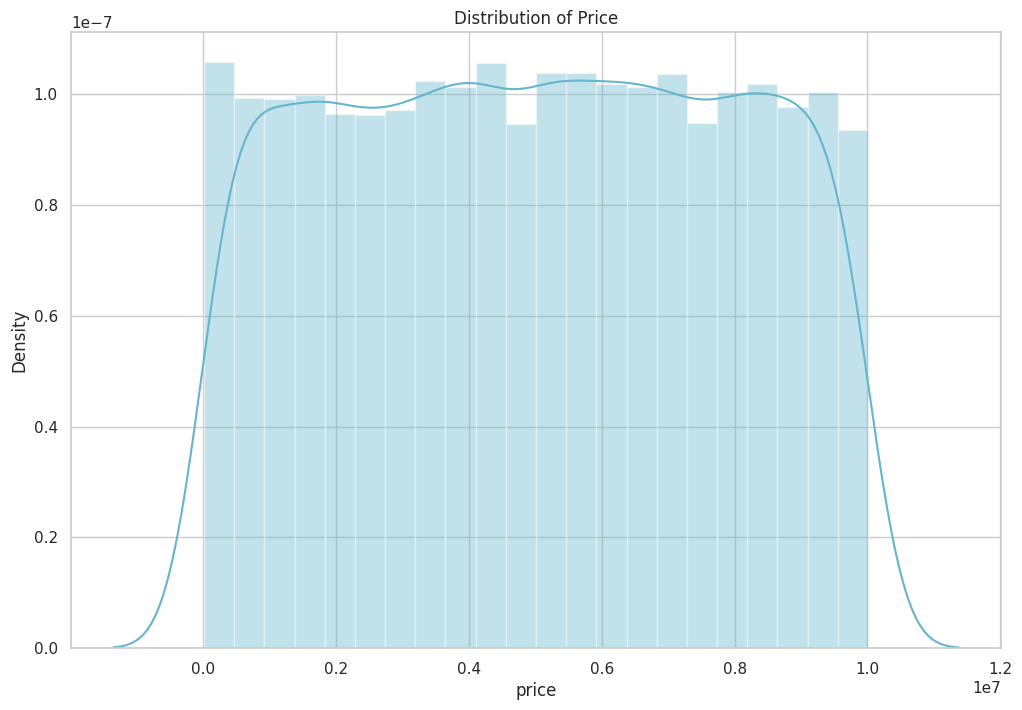

In [ ]:
sns.set(style='whitegrid')
f, ax = plt.subplots(1,1, figsize=(12, 8))
ax = sns.distplot(data['price'], kde = True, color = 'c')
plt.title('Distribution of Price')

dari hasil ploting diatas, menunjukkan bahwa kolom price sebagai target label memiliki distribusi normal (bell curve)

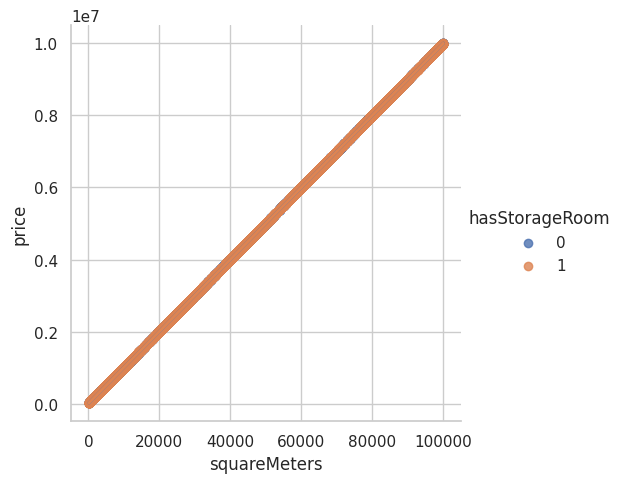

In [ ]:
#plot kolerasi antara kolom squaremeters dengan price
ax = sns.lmplot(x='squareMeters', y='price', hue='hasStorageRoom', data=data)

dari hasil plot diatas menunjukkan adanya hubungan yang signifikan anatara squaremeters dan price. artinya, semakin tinggi squaremeters maka semakin tinggi pricenya

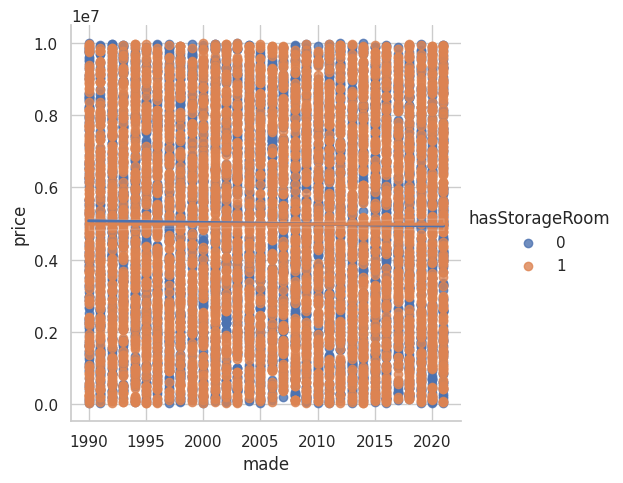

In [ ]:
#plot kolerasi antara kolom made dengan price
ax = sns.lmplot(x='made', y='price', hue='hasStorageRoom', data=data)

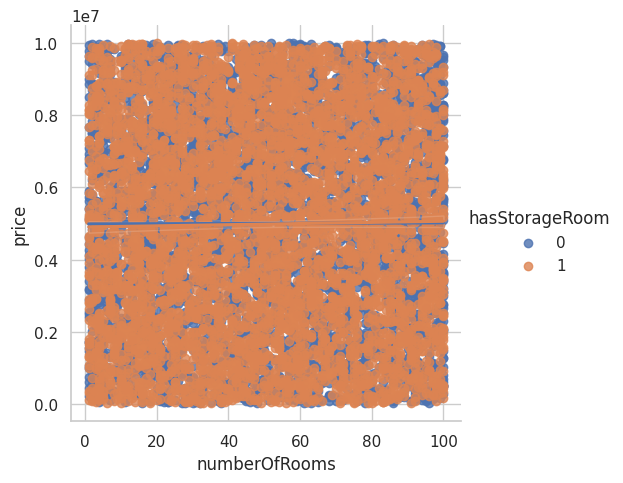

In [ ]:
#plot kolerasi antara kolom numberofrooms dengan price
ax = sns.lmplot(x='numberOfRooms', y='price', hue='hasStorageRoom', data=data)

hasil 2 plot diatas, menunjukkan tidak ada kolerasi antara kolom predictor 'made' dan 'numberOfRooms' terhadap kolom target 'price'

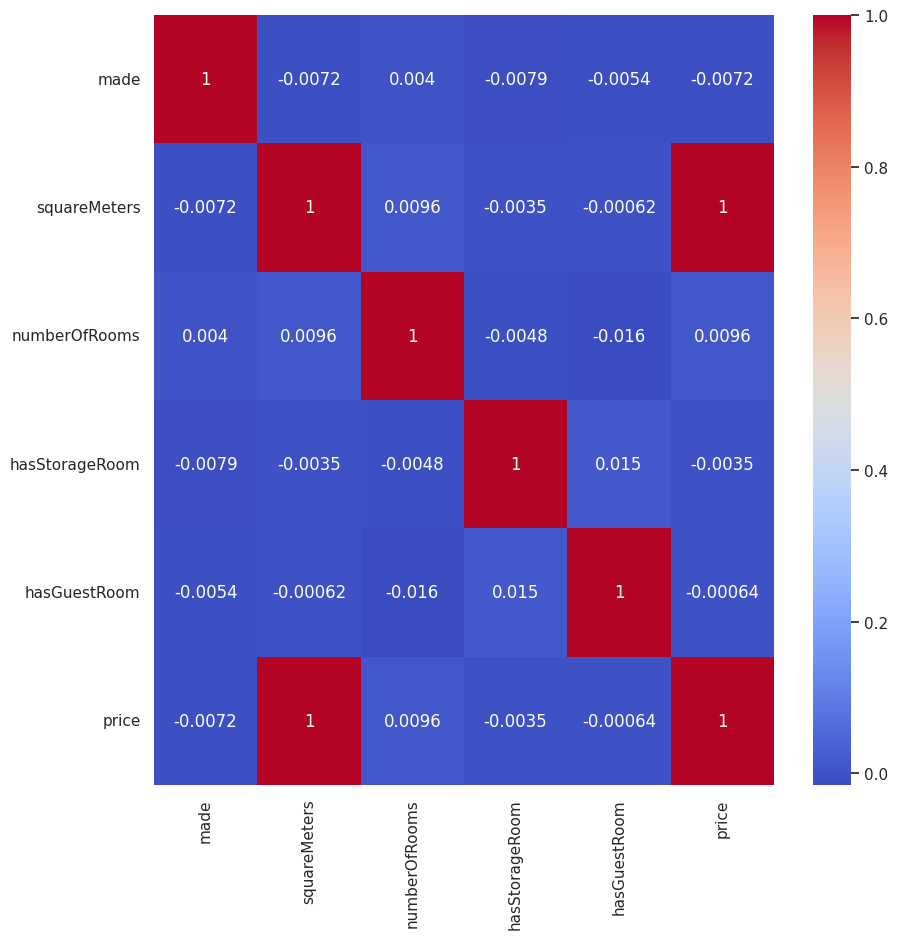

In [ ]:
#heatmap kolerasi
f, ax = plt.subplots(1,1, figsize=(10,10))
ax = sns.heatmap(data.corr(), annot=True, cmap='coolwarm')

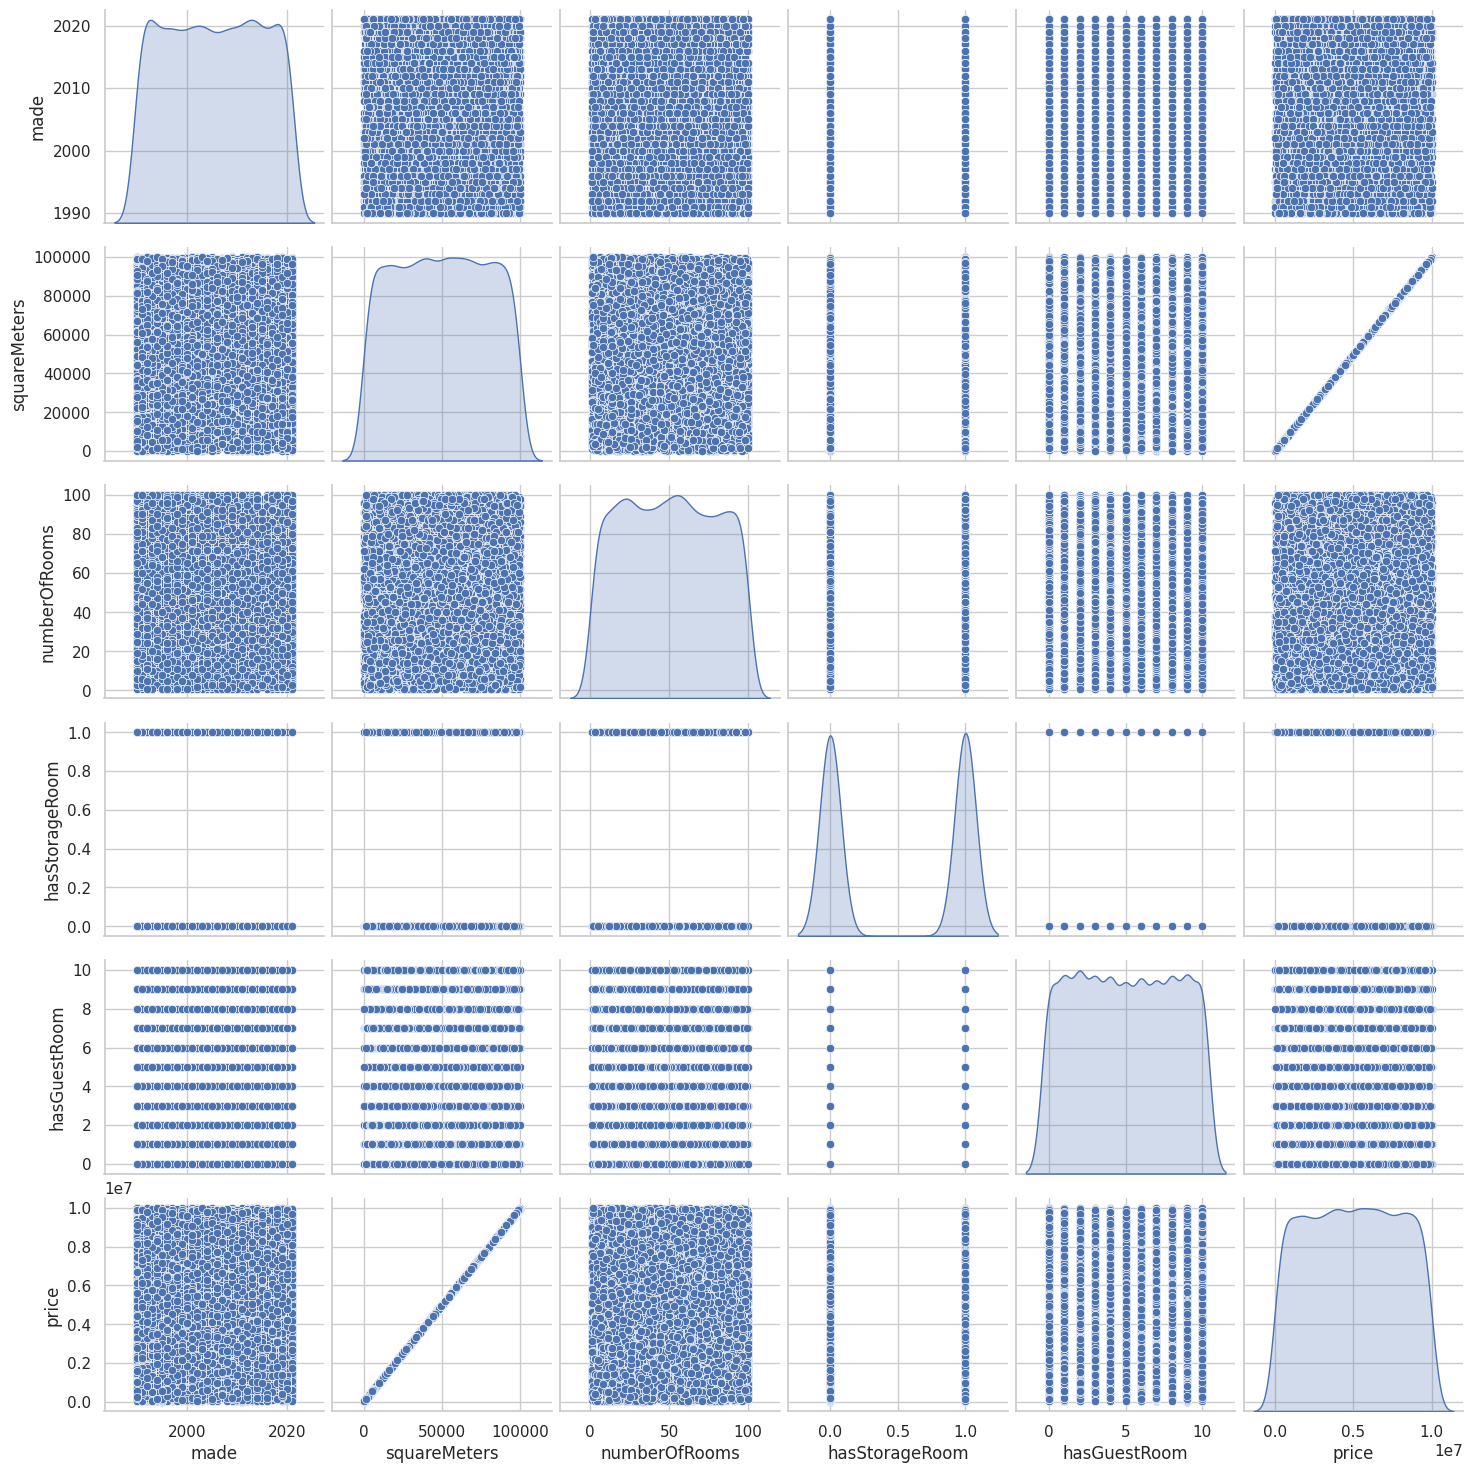

In [ ]:
#pairplot kolerasi
sns.set(style='whitegrid')
sns.pairplot(data, diag_kind='kde')
plt.show()

dari hasil heatmap dan pairplot diatas, kolom yang memiliki hubungan signifikan adalah kolom 'squareMeters' dan kolom 'price'

# Data Pre-processing

In [ ]:
#membuat copy data
dfc= data.copy()

#scalling
scaler = StandardScaler()

#menggunakan fit transform untuk standar scaling
scaled_data=scaler.fit_transform(dfc)

#konversi hasil scaling kembali ke data asl
stdr_data=pd.DataFrame(scaled_data, columns=dfc.columns)
stdr_data

,made,squareMeters,numberOfRooms,hasStorageRoom,hasGuestRoom,price
0,-0.052484,0.891562,-1.643518,-1.006018,0.631373,0.891687
1,1.021904,1.073956,-0.394180,0.994018,-0.942810,1.074814
2,1.666537,0.203033,0.265193,0.994018,1.261046,0.201994
3,0.699588,-0.610092,-0.116549,-1.006018,-0.627973,-0.611997
4,-1.664066,0.714521,-1.088257,0.994018,-0.313136,0.716512
...,...,...,...,...,...,...
9995,0.377271,-1.673244,1.341012,-1.006018,-0.313136,-1.674158
9996,-1.664066,-0.190009,-0.741218,-1.006018,-1.572483,-0.189406
9997,-0.052484,1.180654,-1.643518,0.994018,1.261046,1.180484
9998,0.484710,0.318559,0.681639,0.994018,-0.313136,0.316848


In [ ]:
#data splitting
x=stdr_data.drop(['price'], axis=1) #predictor
y=stdr_data['price'] #label
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Modelling

## Training and Testing Model
Komparasi antara training dan testing score

#linier regression

In [ ]:
lr = LinearRegression()
lr.fit(x_train, y_train)

#prediction
y_train_pred_lr = lr.predict(x_train)
y_test_pred_lr = lr.predict(x_test)

#score
train_score_lr = lr.score(x_train, y_train)
test_score_lr = lr.score(x_test, y_test)

print('Training R2 Score: ', train_score_lr)
print('Testing R2 Score: ', test_score_lr)

#disclaimer linier regression sangat bagus untuk model ini karena squaremetter adalah satu-satunya yang linier dengan price
#score overfitting adalah training - test tidak boleh lebih dari 5%

Training R2 Score:  0.9999986933005185
Testing R2 Score:  0.9999987921640247


In [ ]:
#skor RMSE (mendekati 0 semakin baik)
train_rmse_lr = mean_squared_error(y_train, y_train_pred_lr)
test_rmse_lr = mean_squared_error(y_test, y_test_pred_lr)

print('Training RMSE Score: ', train_rmse_lr)
print('Testing RMSE Score: ', test_rmse_lr)

Training RMSE Score:  1.2870782640892898e-06
Testing RMSE Score:  1.2778682096345334e-06


#lasso regression

In [ ]:
lasso = Lasso(alpha=0.01)
lasso.fit(x_train, y_train)

#prediction
y_train_pred_lasso = lasso.predict(x_train)
y_test_pred_lasso = lasso.predict(x_test)

#score
train_score_lasso = lasso.score(x_train, y_train)
test_score_lasso = lasso.score(x_test, y_test)

print('Training R2 Score (lasso): ', train_score_lasso)
print('Testing R2 Score (lasso): ', test_score_lasso)


Training R2 Score:  0.9998956204896744
Testing R2 Score:  0.9998952557610417


In [ ]:
#skor RMSE (mendekati 0 semakin baik)
train_rmse_lasso = mean_squared_error(y_train, y_train_pred_lasso)
test_rmse_lasso = mean_squared_error(y_test, y_test_pred_lasso)

print('Training RMSE Score (lasso): ', train_rmse_lasso)
print('Testing RMSE Score(lasso): ', test_rmse_lasso)

Training RMSE Score (lasso):  0.0001028121621342717
Testing RMSE Score(lasso):  0.00011081747508188448


#ridge regression

In [ ]:
ridge = Ridge(alpha=0.1)
ridge.fit(x_train, y_train)

#prediction
y_train_pred_ridge= ridge.predict(x_train)
y_test_pred_ridge = ridge.predict(x_test)

#score
train_score_ridge = ridge.score(x_train, y_train)
test_score_ridge = ridge.score(x_test, y_test)

print('Training R2 Score (ridge): ', train_score_ridge)
print('Testing R2 Score(ridge): ', test_score_ridge)

Training R2 Score (ridge):  0.9999986931394378
Testing R2 Score(ridge):  0.9999987917511465


In [ ]:
#skor RMSE (mendekati 0 semakin baik)
train_rmse_ridge = mean_squared_error(y_train, y_train_pred_ridge)
test_rmse_ridge = mean_squared_error(y_test, y_test_pred_ridge)

print('Training RMSE Score (ridge): ', train_rmse_ridge)
print('Testing RMSE Score(ridge): ', test_rmse_ridge)

Training RMSE Score (ridge):  1.2872369260178163e-06
Testing RMSE Score(ridge):  1.2783050271248904e-06


#random forest regression

In [ ]:
rf = RandomForestRegressor()
rf.fit(x_train, y_train)

#prediction
y_train_pred_rf= rf.predict(x_train)
y_test_pred_rf = rf.predict(x_test)

#score
train_score_rf = rf.score(x_train, y_train)
test_score_rf = rf.score(x_test, y_test)

print('Training R2 Score (RF): ', train_score_rf)
print('Testing R2 Score(RF): ', test_score_rf)

Training R2 Score (RF):  0.9999997347259123
Testing R2 Score(RF):  0.9999981350786927


In [ ]:
#skor RMSE (mendekati 0 semakin baik)
train_rmse_rf = mean_squared_error(y_train, y_train_pred_rf)
test_rmse_rf = mean_squared_error(y_test, y_test_pred_rf)

print('Training RMSE Score (RF): ', train_rmse_rf)
print('Testing RMSE Score (RF): ', test_rmse_rf)

Training RMSE Score (RF):  2.612907689413411e-07
Testing RMSE Score (RF):  1.973052385114267e-06


### Berdasarkan hasil di atas, kita akan mengambil model:
1. Ridge Regression
2. Linier regresion

Karena Dari keempat model regresi yang diuji, model Ridge Regression dan Linear Regression dipilih sebagai dua model terbaik karena keduanya memberikan hasil akurasi yang sangat tinggi dengan nilai R² mendekati 1 dan RMSE yang sangat kecil, baik pada data pelatihan maupun data pengujian. Hal ini menunjukkan bahwa kedua model tersebut mampu menangkap hubungan linier antara fitur (misalnya squareMeters) dan target (price) dengan sangat baik, tanpa overfitting. Linear Regression cocok digunakan karena model ini sederhana, mudah diinterpretasikan, dan sangat efektif ketika data memiliki pola hubungan linier yang kuat. Sementara itu, Ridge Regression menawarkan keunggulan tambahan berupa regularisasi L2, yang memberikan perlindungan terhadap multikolinearitas dan variabel tidak stabil, sehingga membuat model lebih tahan terhadap noise dan lebih stabil secara statistik. Dengan mempertimbangkan performa, interpretabilitas, dan ketahanan terhadap overfitting, kedua model ini merupakan pilihan paling ideal untuk kasus regresi linier seperti dataset yang digunakan.

# Model Tuning

In [ ]:
# Model Improvement and Tunning tidak digunakan dalam linier regression

In [ ]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV

# Definisikan parameter yang ingin diuji
lasso_params = {
    'alpha': [0.001, 0.01, 0.1, 1, 10]
}

# GridSearchCV
lasso_grid = GridSearchCV(Lasso(), lasso_params, cv=5, scoring='r2')
lasso_grid.fit(x_train, y_train)

print("Best alpha for Lasso:", lasso_grid.best_params_)
print("Best R2 score (Lasso):", lasso_grid.best_score_)


Best alpha for Lasso: {'alpha': 0.001}
Best R2 score (Lasso): 0.9999976601231098


In [ ]:
from sklearn.linear_model import Ridge

# Definisikan parameter yang ingin diuji
ridge_params = {
    'alpha': [0.001, 0.01, 0.1, 1, 10]
}

# GridSearchCV
ridge_grid = GridSearchCV(Ridge(), ridge_params, cv=5, scoring='r2')
ridge_grid.fit(x_train, y_train)

print("Best alpha for (Ridge):", ridge_grid.best_params_)
print("Best R2 score (RIdge)):", ridge_grid.best_score_)


Best alpha for (Ridge): {'alpha': 0.001}
Best R2 score (RIdge)): 0.9999986914377411


# Kesimpulan

Dari data diatas dapat disimpulkan bahwa:


1.   Data tersebut memiliki hubungan yang sangat kuat secara linier antara fitur utama seperti squareMeters dan target price, terbukti dari skor R² yang sangat tinggi (mendekati 1) dan nilai RMSE yang sangat kecil di berbagai model. Ini menunjukkan bahwa data bersih, tidak banyak outlier, dan cocok untuk digunakan dalam pendekatan regresi.
2.   Model yang paling tepat adalah Linear Regression dan Ridge Regression, karena keduanya memberikan performa prediksi terbaik dengan keseimbangan yang baik antara training dan testing score (tidak overfitting), serta memiliki interpretabilitas yang tinggi. Ridge Regression juga memberikan tambahan kestabilan dengan regularisasi ringan.
3.   Untuk perbaikan maka data ini harus dilakukan eksplorasi lebih lanjut terhadap fitur-fitur lain yang mungkin relevan, seperti variabel kategorikal atau interaksi antar fitur. Selain itu, bisa dilakukan feature engineering (menambah atau mengubah fitur), serta scaling data (jika ingin menguji model lain seperti SVM atau KNN), dan cross-validation agar model lebih general untuk data baru.




Model Deployment


In [ ]:
pickle.dump(lr, open("Maestro_Project.pkl","wb"))

In [ ]:
!pip install pyngrok
!pip install flask

In [ ]:
from flask import Flask, jsonify, request
from pyngrok import ngrok
import pickle # Import the pickle library
import datetime

app = Flask(__name__)

#load model kedalam API
with open ("Maestro_Project.pkl", "rb") as file:
  model = pickle.load(file)

#rute default atau home
@app.route ("/" , methods = ["GET"])
def index():
  return jsonify({"Nama":"Alya Devi Anjani","Status":"API DIJALANKAN"})
@app.route("/predict", methods=["POST"])
def predict():
    try:
        data = request.get_json(force=True)

        # --- Ambil & validasi satu-per-satu ---
        made = int(data["made"])
        squareMeters   = float(data["squareMeters"])
        numberOfRooms  = int(data["numberOfRooms"])
        hasStorageRoom = int(data["hasStorageRoom"])
        hasGuestRoom   = int(data["hasGuestRoom"])

        # Validasi logis
        if not (1900 <= made <= datetime.datetime.now().year):
            return jsonify({"STATUS": "GAGAL - TAHUN PEMBUATAN TIDAK MASUK AKAL"})
        if squareMeters <= 0:
            return jsonify({"STATUS": "GAGAL - LUAS HARUS POSITIF"})
        if not (0 <= numberOfRooms <= 100):
            return jsonify({"STATUS": "GAGAL - JUMLAH RUANGAN TIDAK VALID"})
        if hasStorageRoom not in [0, 1] or hasGuestRoom not in [0, 1]:
            return jsonify({"STATUS": "GAGAL - NILAI BOOLEAN SALAH (0/1)"})

        # Prediksi
        features = [[made, squareMeters, numberOfRooms, hasStorageRoom, hasGuestRoom]]
        prediction = model.predict(features)[0]

        data["Prediction"] = prediction
        data["Timestamp"] = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")

        #menampung data testing
        with open("data_collection.txt", "a") as file2:
            file2.write(str(data) + "\n")

        return jsonify({"Status": "Sukses", "Prediction": float(prediction)})

    except KeyError as e:
        return jsonify({"STATUS": f"GAGAL - kolom {e.args[0]} tidak ditemukan"})
    except Exception as e:
        # log error ke console
        print("ERROR:", e)
        return jsonify({"STATUS": "GAGAL - internal error"}), 500


#jalankan API
if __name__ == "__main__":
  ngrok.set_auth_token ("30jExANgv6QxsngIIcUa3UPXn5G_5jJXzpFCLvn94shEkMPzh")
  ngrok_tunnel = ngrok.connect(5000)
  print('Public URL:', ngrok_tunnel.public_url)
  app.run()

Public URL: https://a81d6880b94e.ngrok-free.app
 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
INFO:werkzeug:127.0.0.1 - - [04/Aug/2025 13:05:55] "POST /predict HTTP/1.1" 200 -
